In [9]:
from google.colab import drive
drive.mount('/content/drive') 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

dataset_path = '/kaggle/input/skin-cancer-mnist-ham10000'
csv_path = os.path.join(dataset_path, 'HAM10000_metadata.csv')

df = pd.read_csv(csv_path)

mapeamento_lesoes = {
    'nv': 'Nevo Melanocitico (Benigno)',
    'mel': 'Melanoma (Maligno)',
    'bcc': 'Carcinoma Basocelular (Maligno)',  
    'akiec': 'Queratose Actinica (Pre-Maligno)',
    'bkl': 'Queratose Benigna (Benigno)',
    'df': 'Dermatofibroma (Benigno)',
    'vasc': 'Lesao Vascular (Benigno)'
}

df['dx'] = df['dx'].map(mapeamento_lesoes)

def caminho_da_imagem(image_id):
    nome_arquivo = f"{image_id}.jpg"
    caminho_part1 = os.path.join(dataset_path, 'ham10000_images_part_1', nome_arquivo)
    if os.path.exists(caminho_part1):
        return caminho_part1
    return os.path.join(dataset_path, 'ham10000_images_part_2', nome_arquivo)

df['image_path'] = df['image_id'].apply(caminho_da_imagem)
df['label_idx'] = pd.Categorical(df['dx']).codes

train_df, val_df = train_test_split(df, test_size=0.4, random_state=42, stratify=df['label_idx'])
val_df, test_df = train_test_split(val_df, test_size=0.4, random_state=42, stratify=val_df['label_idx'])

maior_classe = df['dx'].value_counts().index[0]
print(f"Proporção no Treino:    {(train_df['dx'] == maior_classe).mean():.2%}")
print(f"Proporção na Validação: {(val_df['dx'] == maior_classe).mean():.2%}")
print(f"Proporção no Teste:     {(test_df['dx'] == maior_classe).mean():.2%}")


Proporção no Treino:    66.95%
Proporção na Validação: 66.96%
Proporção no Teste:     66.94%


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_idx']),
    y=train_df['label_idx']
)


dicionario_pesos = dict(zip(np.unique(train_df['label_idx']), pesos))


In [ ]:
import tensorflow as tf

def carregar_e_processar_classificacao(caminho_img, label):

    img_raw = tf.io.read_file(caminho_img)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0
    
    return img, label

batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label_idx'].values))
train_dataset = train_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_df['image_path'].values, val_df['label_idx'].values))
val_dataset = val_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)


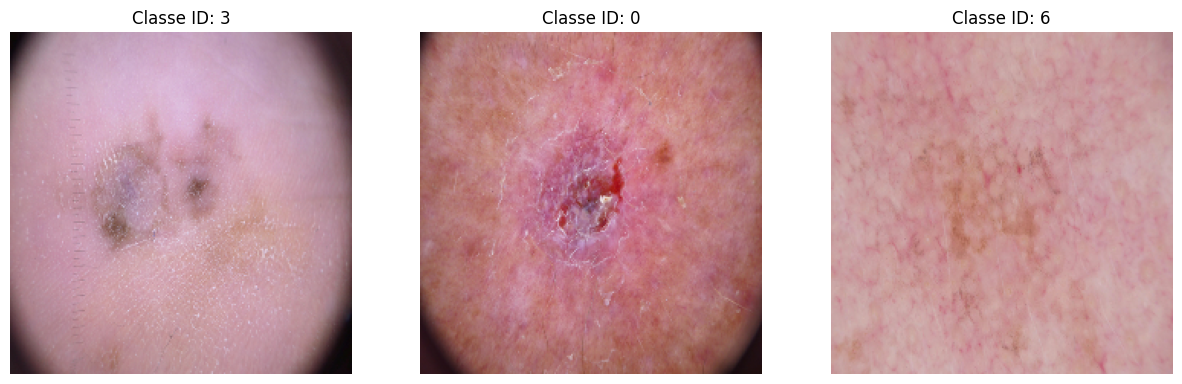

In [ ]:
import matplotlib.pyplot as plt

for imagens_lote, labels_lote in train_dataset.take(1):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
    
    for i in range(3):

        axes[i].imshow(imagens_lote[i].numpy())
        

        classe_id = int(labels_lote[i])
        axes[i].set_titlco: Você terá 262 passos na barra do MobileNetV2. O modelo vai treinar perfeitamente e o impacto na velocidade por usar um ne(f"Classe ID: {classe_id}")
        
        axes[i].axis('off')
        
    plt.show()

In [ ]:
from tensorflow.keras import layers, Model, Input

inputs = Input(shape=(224, 224, 3))


base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False


x = base_model(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.6)(x)


outputs = layers.Dense(7, activation='softmax', name="output_classificacao")(x)

model = Model(inputs=inputs, outputs=outputs)


for k, v in dicionario_pesos.items():
    print(f"• Classe {k}: Peso {v:.2f}")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)


model.summary()

• Classe 0: Peso 2.79
• Classe 1: Peso 12.44
• Classe 2: Peso 10.10
• Classe 3: Peso 1.29
• Classe 4: Peso 0.21
• Classe 5: Peso 4.38
• Classe 6: Peso 1.30


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_classificacao (Dense)    │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,306 (16.71 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 90s 329ms/step - accuracy: 0.6632 - loss: 1.2240 - val_accuracy: 0.6696 - val_loss: 1.1378
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 52s 252ms/step - accuracy: 0.6693 - loss: 1.2020 - val_accuracy: 0.6696 - val_loss: 1.1466
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 247ms/step - accuracy: 0.6695 - loss: 1.1879 - val_accuracy: 0.6696 - val_loss: 1.1341
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 52s 256ms/step - accuracy: 0.6695 - loss: 1.1829 - val_accuracy: 0.6696 - val_loss: 1.1355
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 211ms/step - accuracy: 0.6695 - loss: 1.1857 - val_accuracy: 0.6696 - val_loss: 1.1358
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 43s 208ms/step - accuracy: 0.6695 - loss: 1.1753 - val_accuracy: 0.6696 - val_loss: 1.1355
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 91s 255ms/step - accuracy: 0.6695 - loss: 1.1665 - val_accuracy: 0.6696 - val_loss: 1.1499
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 53s 255ms/step - accuracy: 0.6695 - loss: 1

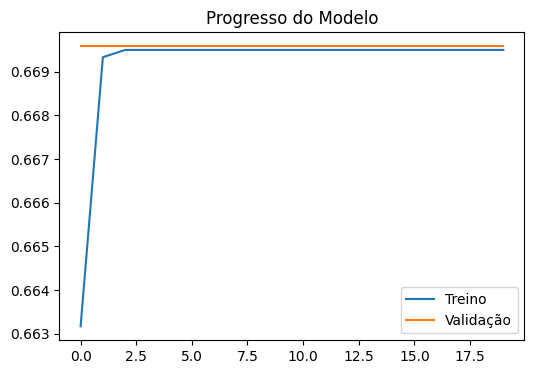

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, acc, label='Treino')
plt.plot(epochs_range, val_acc, label='Validação')
plt.title('Progresso do Modelo')
plt.legend()
plt.show()

In [ ]:

train_df = pd.concat([train_df, val_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label_idx'].values))
train_dataset = train_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_df['image_path'].values, test_df['label_idx'].values))
test_dataset = test_dataset.map(carregar_e_processar_classificacao, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)


model.fit(train_dataset, epochs=3)

Epoch 1/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 62s 214ms/step - accuracy: 0.6695 - loss: 1.1444
Epoch 2/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 63s 142ms/step - accuracy: 0.6695 - loss: 1.1440
Epoch 3/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 43s 141ms/step - accuracy: 0.6695 - loss: 1.1444


51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 351ms/step


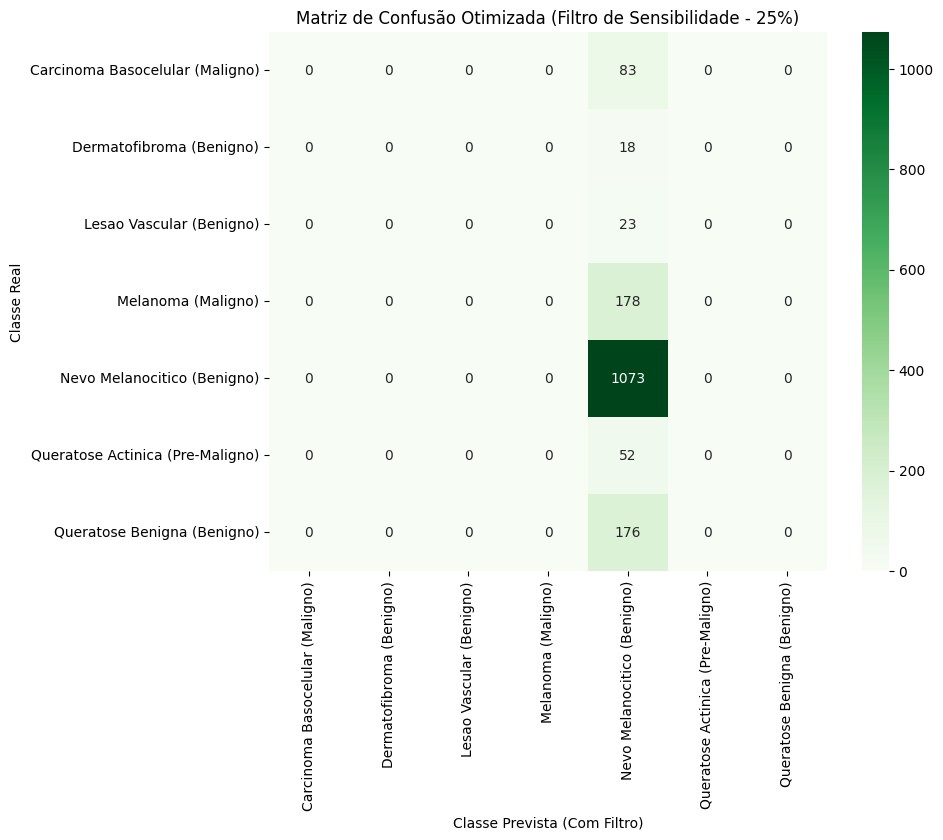

                                  precision    recall  f1-score   support

 Carcinoma Basocelular (Maligno)       0.00      0.00      0.00        83
        Dermatofibroma (Benigno)       0.00      0.00      0.00        18
        Lesao Vascular (Benigno)       0.00      0.00      0.00        23
              Melanoma (Maligno)       0.00      0.00      0.00       178
     Nevo Melanocitico (Benigno)       0.67      1.00      0.80      1073
Queratose Actinica (Pre-Maligno)       0.00      0.00      0.00        52
     Queratose Benigna (Benigno)       0.00      0.00      0.00       176

                        accuracy                           0.67      1603
                       macro avg       0.10      0.14      0.11      1603
                    weighted avg       0.45      0.67      0.54      1603



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Gerar as probabilidades direto no dataset de TESTE (15%)
predicoes_prob = model.predict(test_dataset)

# Índices numéricos das suas classes malignas
idx_carcinoma = 0  
idx_melanoma = 3   

predicoes_finais = []

# 2. Aplicar o filtro de sensibilidade médica (Threshold)
for prob in predicoes_prob:
    if prob[idx_melanoma] > 0.35:
        predicoes_finais.append(idx_melanoma)
    elif prob[idx_carcinoma] > 0.35:
        predicoes_finais.append(idx_carcinoma)
    else:
        predicoes_finais.append(np.argmax(prob))

predicoes_finais = np.array(predicoes_finais)

# 3. Extrair as respostas reais do dataset de teste
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# 4. Pegar os nomes das classes
classes_nomes = pd.Categorical(df['dx']).categories.tolist()

# 5. Gerar a Matriz usando 'predicoes_finais' (AQUI ESTÁ A CORREÇÃO!)
cm = confusion_matrix(y_true, predicoes_finais)

# Plotar o Gráfico Otimizado
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes_nomes, yticklabels=classes_nomes)
plt.title('Matriz de Confusão Otimizada (Filtro de Sensibilidade - 25%)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista (Com Filtro)')
plt.show()

# 6. Exibir o Relatório usando 'predicoes_finais'
print(classification_report(y_true, predicoes_finais, target_names=classes_nomes))

Classe Real: Nevo Melanocitico (Benigno)


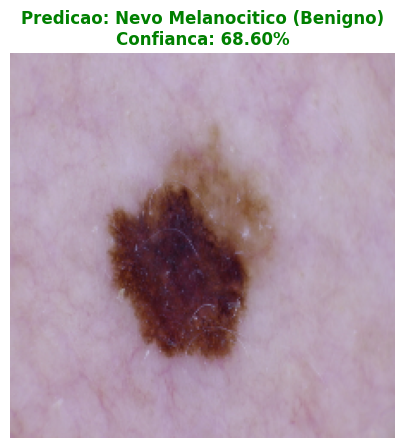

In [ ]:
def predizer_lesao(caminho_imagem_nova, modelo_treinado, lista_classes):
    
    img_raw = tf.io.read_file(caminho_imagem_nova)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0 
    
    img_lote = tf.expand_dims(img, axis=0)
    

    predicoes = modelo_treinado.predict(img_lote, verbose=0)
    
    indice_vencedor = np.argmax(predicoes[0])
    classe_vencedora = lista_classes[indice_vencedor]
    confianca = predicoes[0][indice_vencedor] * 100
    

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    
    
    if "Maligno" in classe_vencedora:
        cor_titulo = 'red'
    elif "Pre-Maligno" in classe_vencedora:
        cor_titulo = 'orange'
    else:
        cor_titulo = 'green'
        
    plt.title(f"Predicao: {classe_vencedora}\nConfianca: {confianca:.2f}%", 
              color=cor_titulo, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()
    
    return classe_vencedora, confianca


imagem = int(9)

test = test_df['image_path'].iloc[imagem] 
real = test_df['dx'].iloc[imagem]


classes_nomes = pd.Categorical(df['dx']).categories.tolist()

print(f"Classe Real: {real}")



classe_prevista, certeza = predizer_lesao(test, model, classes_nomes)

In [ ]:
from google.colab import files

model.save_weights("pesos_efficientnet_B0.weights.h5")